In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
from pyomo.environ import *
from optimization_utils import *
# from data_processing_utils import get_ramps_per_segment, get_lanes_per_segment
from param_loader import METANET_Params
from mpc_utils import *
from simulation_utils import *
import math
# CHANGED: Import from new package
# from metanet_calibration.metanet_dynamics import run_metanet_sim
# from metanet_calibration.ipopt_optimization import smooth_inflow
# from metanet_calibration.data_processing import plot_simulation_comparison, mape


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
T = 10 / 3600
l = 0.4
num_calibrated_segments = 14
include_ramping = True
varylanes = False

In [4]:
from pathlib import Path
import numpy as np
import re


def _load_average_over_all_segments(cache_dir, cfg, perturb_pct):
    """
    Load all cached segment files for this config and return the average result
    across segments for each perturbation key.

    Assumes cache files were saved one segment at a time.
    """
    cache_dir = Path(cache_dir)
    label = cfg["label"].replace(" ", "_").replace("/", "_")
    bc_timestep = cfg.get("bc_timestep", 180)

    # Match files like:
    # label_seg7_bc180_n201_pmin-0.1000_pmax0.1000.npz
    pattern = re.compile(
        rf"^{re.escape(label)}_seg(\d+)_bc{bc_timestep}"
        rf"_n{len(perturb_pct)}"
        rf"_pmin{perturb_pct[0]:.4f}"
        rf"_pmax{perturb_pct[-1]:.4f}\.npz$"
    )

    matching_files = []
    for f in cache_dir.glob("*.npz"):
        if pattern.match(f.name):
            matching_files.append(f)

    if not matching_files:
        raise FileNotFoundError(
            f"No cached segment files found in {cache_dir} for label='{cfg['label']}' "
            f"with bc_timestep={bc_timestep} and the requested perturbation grid."
        )

    matching_files = sorted(matching_files)
    print(f"  Found {len(matching_files)} cached segment files. Averaging over all segments...")

    loaded_results = []
    loaded_pct_ref = None

    for f in matching_files:
        results, loaded_pct, meta = _load_perturbation_results(f)

        if loaded_pct_ref is None:
            loaded_pct_ref = loaded_pct
        elif not np.allclose(loaded_pct_ref, loaded_pct):
            raise ValueError(f"Perturbation grid mismatch in cache file: {f}")

        loaded_results.append(results)

    keys = loaded_results[0].keys()
    avg_results = {}

    for key in keys:
        stacked = np.stack([res[key] for res in loaded_results], axis=0)
        avg_results[key] = np.mean(stacked, axis=0)

    metadata = {
        "label": cfg["label"],
        "segment_idx": "all",
        "bc_timestep": bc_timestep,
        "num_segments_averaged": len(matching_files),
    }

    return avg_results, loaded_pct_ref, metadata

In [ ]:
g_fontsize = 12


In [12]:
def compute_perturbation_mapes(T, l, num_calibrated_segments,
                                run_metanet_sim, mape_fn,
                                rho_hat, q_hat, v_hat, params,
                                lanes, base_rho_init, base_downstream, base_inflow,
                                segment_idx=7, bc_timestep=180,
                                perturb_pct=np.arange(-0.1, 0.101, 0.001)):
    """
    Compute MAPE curves for ±perturbation of each parameter/BC.
    
    All preprocessing (smoothing, lane selection) is done by the caller,
    so this function just runs the sim with whatever it's given.
    """

    def run_sim(perturbed_params, downstream_density, data_inflow, rho_init):
        init_traffic_state = (rho_init[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
        rho_sim, v_sim, queue_sim, tts_sim = run_metanet_sim(
            T=T, l=l,
            init_traffic_state=init_traffic_state,
            demand=data_inflow,
            downstream_density=downstream_density,
            params=perturbed_params,
            vsl_speeds=None,
            lanes=lanes,
            plotting=True,
            real_data=True,
        )
        return v_sim

    v_true_interior = v_hat[:, 1:-1]

    # Sanity check
    v_sim_baseline = run_sim(params, base_downstream, base_inflow, base_rho_init)
    baseline_mape = mape_fn(v_true_interior, v_sim_baseline[:-1, :])
    print(f"  Baseline MAPE: {baseline_mape:.4f}")

    param_keys = ['eta_high', 'K', 'tau', 'p_crit', 'v_free', 'a']
    bc_keys = [] #['downstream_density', 'initial_flow']
    all_keys = param_keys + bc_keys

    results = {}
    for key in all_keys:
        print(f"  Perturbing {key}...")
        mape_list = []
        for pct in perturb_pct:
            p_params = {k: np.array(v, dtype=float).copy() for k, v in params.items()}
            p_downstream = base_downstream.copy()
            p_inflow = base_inflow.copy()

            if key == 'downstream_density':
                p_downstream[bc_timestep] *= (1 + pct)
            elif key == 'initial_flow':
                p_inflow[bc_timestep] *= (1 + pct)
            else:
                param_arr = np.array(params[key], dtype=float)
                if param_arr.ndim == 1:
                    p_params[key][segment_idx] = param_arr[segment_idx] * (1 + pct)
                elif param_arr.ndim == 2:
                    p_params[key][:, segment_idx] = param_arr[:, segment_idx] * (1 + pct)
                else:
                    p_params[key] = float(param_arr) * (1 + pct)

            v_sim = run_sim(p_params, p_downstream, p_inflow, base_rho_init)
            mape_list.append(mape_fn(v_true_interior, v_sim[:-1, :]))

        results[key] = np.array(mape_list)

    return results

def _make_cache_name(cfg, perturb_pct):
    segment_idx = cfg.get("segment_idx", 7)
    if segment_idx == "all":
        raise ValueError(
            "segment_idx='all' is an aggregate view and should be loaded from "
            "existing per-segment cache files, not saved as a direct run."
        )

    bc_timestep = cfg.get("bc_timestep", 180)
    label = cfg["label"].replace(" ", "_").replace("/", "_")
    return (
        f"{label}"
        f"_seg{segment_idx}"
        f"_bc{bc_timestep}"
        f"_n{len(perturb_pct)}"
        f"_pmin{perturb_pct[0]:.4f}"
        f"_pmax{perturb_pct[-1]:.4f}.npz"
    )


def _save_perturbation_results(filepath, results, perturb_pct, cfg):
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)

    save_dict = {
        "perturb_pct": np.array(perturb_pct, dtype=float),
        "keys": np.array(list(results.keys()), dtype=object),
        "label": np.array(cfg["label"], dtype=object),
        "segment_idx": np.array(cfg.get("segment_idx", 7)),
        "bc_timestep": np.array(cfg.get("bc_timestep", 180)),
    }

    for k, v in results.items():
        save_dict[f"result__{k}"] = np.array(v)

    np.savez_compressed(filepath, **save_dict)
    print(f"  Saved perturbation data to: {filepath}")


def _load_perturbation_results(filepath):
    filepath = Path(filepath)
    data = np.load(filepath, allow_pickle=True)

    perturb_pct = data["perturb_pct"]
    keys = [str(k) for k in data["keys"]]

    results = {}
    for k in keys:
        results[k] = data[f"result__{k}"]

    metadata = {
        "label": str(data["label"].item()) if "label" in data else None,
        "segment_idx": int(data["segment_idx"]) if "segment_idx" in data else None,
        "bc_timestep": int(data["bc_timestep"]) if "bc_timestep" in data else None,
    }

    return results, perturb_pct, metadata


def run_and_plot_perturbations(param_configs, T, l, num_calibrated_segments,
                               run_metanet_sim, mape_fn,
                               perturb_pct=np.arange(-0.1, 0.101, 0.001),
                               save_path=None,
                               cache_dir="perturbation_cache",
                               use_cache=True,
                               load_only=False):

    # ── Load shared ground truth data ─────────────────────────────────────────
    rho_hat = np.load("data/density_10sec_400m_1hr.npy")
    q_hat = np.load("data/flow_10sec_400m_1hr.npy")
    v_hat = q_hat / rho_hat

    lane_mapping = np.load("data/lane_mapping.npy")
    rho_hat = rho_hat / lane_mapping

    # ── Run or load perturbation for each config ──────────────────────────────
    all_results = {}
    loaded_perturb_pct = None
    cache_dir = Path(cache_dir)

    for cfg in param_configs:
        label = cfg["label"]
        true_labels = {"OCP": "Static", "MPC_90": "Dynamic \n (Ours)", "RL": "RL"}
        segment_idx = cfg.get("segment_idx", 7)

        print(f"\n{'='*50}")
        print(f"Config: {label} ({cfg['results_dir']})")
        print(f"Segment: {segment_idx}")
        print(f"{'='*50}")

        # Special case: average all cached segment results
        if segment_idx == "all":
            if not (use_cache or load_only):
                raise ValueError(
                    "segment_idx='all' only supports loading from cache. "
                    "Run and save individual segments first, then use segment_idx='all'."
                )

            results, loaded_pct, meta = _load_average_over_all_segments(
                cache_dir=cache_dir,
                cfg=cfg,
                perturb_pct=perturb_pct,
            )
            all_results[label] = results
            loaded_perturb_pct = loaded_pct
            continue

        cache_file = cache_dir / _make_cache_name(cfg, perturb_pct)
        print(f"Cache:  {cache_file}")

        if cache_file.exists() and (use_cache or load_only):
            print("  Loading existing perturbation data...")
            results, loaded_pct, meta = _load_perturbation_results(cache_file)
            all_results[label] = results
            loaded_perturb_pct = loaded_pct
            continue

        if load_only:
            raise FileNotFoundError(
                f"load_only=True, but cache file does not exist:\n{cache_file}"
            )

        print("  No cache found, running perturbations...")

        params = METANET_Params(
            path=cfg["results_dir"],
            control_h=cfg["control_hor"],
            num_segments=num_calibrated_segments,
            num_timesteps=rho_hat.shape[0]
        ).get_params()

        lanes = {i: cfg["lanes"][i] for i in range(num_calibrated_segments)}

        if cfg.get("smooth_rho", False):
            base_rho_init = smooth_inflow(rho_hat[:, 1:-1])
        else:
            base_rho_init = rho_hat[:, 1:-1].copy()

        if cfg.get("smooth_bc", False):
            base_downstream = smooth_inflow(rho_hat[:, -1])
            base_inflow = smooth_inflow(q_hat[:, 0])
        else:
            base_downstream = rho_hat[:, -1].copy()
            base_inflow = q_hat[:, 0].copy()

        results = compute_perturbation_mapes(
            T=T, l=l,
            num_calibrated_segments=num_calibrated_segments,
            run_metanet_sim=run_metanet_sim,
            mape_fn=mape_fn,
            rho_hat=rho_hat, q_hat=q_hat, v_hat=v_hat,
            params=params,
            lanes=lanes,
            base_rho_init=base_rho_init,
            base_downstream=base_downstream,
            base_inflow=base_inflow,
            segment_idx=segment_idx,
            bc_timestep=cfg.get("bc_timestep", 180),
            perturb_pct=perturb_pct,
        )

        all_results[label] = results
        _save_perturbation_results(cache_file, results, perturb_pct, cfg)

    # If loaded from file, use the saved perturbation axis
    if loaded_perturb_pct is not None:
        perturb_pct = loaded_perturb_pct

    # ── Plotting ──────────────────────────────────────────────────────────────
    # Plotting
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": "Times New Roman", #["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],  # Use Computer Modern for text
        "mathtext.fontset": "cm",   # Computer Modern for math
        "pdf.fonttype": 42,  # Embed fonts in PDF output
        "ps.fonttype": 42,  # Embed fonts in PS output
        "axes.unicode_minus": False,
        "text.usetex": False
    })
    
    perturb_x = perturb_pct * 100
    zero_idx = np.argmin(np.abs(perturb_pct))
    all_keys = ['eta_high', 'K', 'tau', 'p_crit', 'v_free', 'a']

    # LaTeX/Greek subplot titles
    title_map = {
        'eta_high': r'$\eta$',
        'K': r'$\kappa$',
        'tau': r'$\tau$',
        'p_crit': r'$\rho_{\mathrm{cr}}$',
        'v_free': r'$v_{\mathrm{free}}$',
        'a': r'$a$',
        'downstream_density': r'$\rho_{\mathrm{down}}$',
        'initial_flow': r'$q_{\mathrm{in}}$',
    }

    n_keys = len(all_keys)
    nrows = 1 if n_keys < 3 else 2
    ncols = math.ceil(n_keys / nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    colors = ["orange", "#BB4EFF", "blue"]#plt.cm.tab10.colors

    legend_handles = []
    for idx, label in enumerate(all_results):
        color = colors[idx % len(colors)]
        legend_handles.append(
            Line2D([0], [0], color=color, linewidth=1.5, label=true_labels[label])
        )

    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(1.02, 1.03),
        frameon=True,
        fontsize=legend_fs,
    )

    # -------------------------------------------------------------------------
    # First pass: compute global y-limits shared by all subplots
    # -------------------------------------------------------------------------
    global_ymin = np.inf
    global_ymax = -np.inf

    for key in all_keys:
        for label, results in all_results.items():
            baseline = results[key][zero_idx]
            yvals = results[key] - baseline
            global_ymin = min(global_ymin, np.min(yvals))
            global_ymax = max(global_ymax, np.max(yvals))

    # Optional padding so lines do not sit on the border
    if np.isclose(global_ymin, global_ymax):
        pad = 1e-6 if global_ymin == 0 else 0.05 * abs(global_ymin)
    else:
        pad = 0.05 * (global_ymax - global_ymin)

    global_ymin -= pad
    global_ymax += pad

    # -------------------------------------------------------------------------
    # Second pass: plot
    # -------------------------------------------------------------------------
    for plot_idx, (ax, key) in enumerate(zip(axes[:n_keys], all_keys)):
        ax.set_facecolor('white')

        for idx, (label, results) in enumerate(all_results.items()):
            color = colors[idx % len(colors)]
            baseline = results[key][zero_idx]
            ax.plot(perturb_x, results[key] - baseline, color=color, linewidth=2)

        ax.axvline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.7)
        ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.7)
        ax.grid(True, color='lightgrey', linewidth=0.5, linestyle='-', alpha=0.8)
        ax.set_axisbelow(True)

        ax.set_title(title_map.get(key, key), fontsize=title_fs, fontweight='normal', pad=6)
        ax.set_xlim(perturb_x[0], perturb_x[-1])
        ax.set_ylim(global_ymin, global_ymax)
        ax.tick_params(labelsize=tick_fs)

        # Only show x-axis on bottom row
        row_idx = plot_idx // ncols
        is_bottom_row = (row_idx == nrows - 1)

        if is_bottom_row:
            ax.set_xlabel('Perturbation (%)', fontsize=label_fs)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False)

        # Only show y-axis label on left column
        col_idx = plot_idx % ncols
        is_left_col = (col_idx == 0)

        if is_left_col:
            ax.set_ylabel('\u0394MAPE from baseline (%)', fontsize=label_fs)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', which='both', labelleft=False)

        for spine in ax.spines.values():
            spine.set_edgecolor('#cccccc')
            spine.set_linewidth(0.8)

    # hide any unused axes
    for ax in axes[n_keys:]:
        ax.set_visible(False)

    # Optional overall title
    # fig.suptitle(
    #     f'Sensitivity Analysis — Segment {param_configs[0].get("segment_idx", 7)} | '
    #     f'BC Timestep {param_configs[0].get("bc_timestep", 180)}',
    #     fontsize=suptitle_fs,
    #     y=1.02
    # )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"\nSaved plot to {save_path}")

    plt.show()
    return all_results



Config: OCP (itsc_final/calibration_results/OCP)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/OCP_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...

Config: MPC_90 (itsc_final/smooth_mpc_calibration_results/)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/MPC_90_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...

Config: RL (calibration_results/i24_11_30_rl_posttrain_2/)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/RL_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp



Saved plot to smooth_landscape_plots/sensitivity_comparison_rl_segment0.pdf


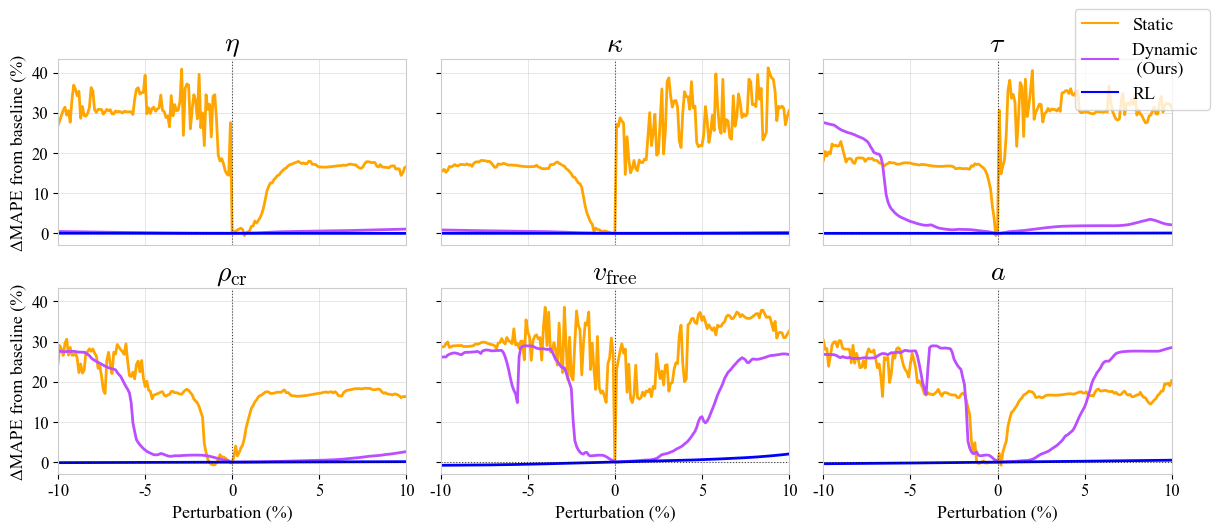

In [13]:
# Each config specifies its own lanes and preprocessing, matching standalone cells
lanes = np.load("data/lane_mapping.npy")

i24_rho = np.load("data/density_10sec_400m_1hr.npy") / lanes
i24_q = np.load("data/flow_10sec_400m_1hr.npy")

seg = 0
param_configs = [
    {
        "label": "OCP",
        "results_dir": "itsc_final/calibration_results/OCP",
        "control_hor": None,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    },
    {
        "label": "MPC_90",
        "results_dir": "itsc_final/smooth_mpc_calibration_results/",
        "control_hor": 90,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    },
    {
        "label": "RL",
        "results_dir": "calibration_results/i24_11_30_rl_posttrain_2/",
        "control_hor": None,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    }
]

all_results = run_and_plot_perturbations(
    param_configs=param_configs,
    T=T, l=l,
    num_calibrated_segments=num_calibrated_segments,
    run_metanet_sim=run_metanet_sim,
    mape_fn=mape,
    save_path=f"smooth_landscape_plots/sensitivity_comparison_rl_segment{seg}.pdf",
    cache_dir="smooth_landscape_plots/perturbation_cache",
    use_cache=True,
    load_only=False
)


In [131]:
# Standalone simulation cell (for verifying baseline MAPE)
print("Simulating with calibrated parameters...")
rho_hat = np.load("data/rho_hat.npy")
q_hat = np.load("data/q_hat.npy")
v_hat = np.load("data/v_hat.npy")
num_lanes_array = [4]*num_calibrated_segments
num_calibrated_segments = 14
T = 10/3600
l = 0.4

total_rho_hat = rho_hat[:, 1:-1]
downstream_density = smooth_inflow(rho_hat[:, -1])
data_inflow = smooth_inflow(q_hat[:, 0])

init_traffic_state = (total_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
RESULTS_DIR = "robust_S10_0001"
params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()

rho_sim_new, v_sim_new, queue_sim, tts_sim = run_metanet_sim(
    T, l, init_traffic_state, data_inflow, downstream_density, params,
    vsl_speeds=None,
    lanes={i: num_lanes_array[i] for i in range(num_calibrated_segments)},
    plotting=True, real_data=True
)
plot_simulation_comparison(rho_sim_new, v_sim_new, rho_hat, v_hat, q_true=q_hat, include_fd=True, save_path=None)
print(f"Standalone MAPE: {mape(v_hat[:, 1:-1], v_sim_new[:-1, :]):.4f}")


Simulating with calibrated parameters...


FileNotFoundError: [Errno 2] No such file or directory: 'data/rho_hat.npy'